# Customer Churn Prediction (Binary Classification)

**Project Objective:** Build machine learning models that accurately predict whether a telecom customer will churn, enabling proactive retention strategies.

**Models Covered:** Logistic Regression · Random Forest · Support Vector Machine (SVM) · K-Nearest Neighbors (KNN) · XGBoost · LightGBM

---

## Step 1: Setup Importing Libraries & Loading Data

In [2]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipelines
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb

# Class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import SelectFromModel


In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Dataset: IBM Telco Customer Churn
# Download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# Place 'WA_Fn-UseC_-Telco-Customer-Churn.csv' in the working directory

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Exploratory Data Analysis (EDA)

Before building models, we examine the target distribution, feature characteristics, and relationships to churn.

In [4]:
# Dataset overview
print("Dataset Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print(f"\nTotal missing values: {df.isna().sum().sum()}")
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str  

### 2.1 Target Variable Distribution

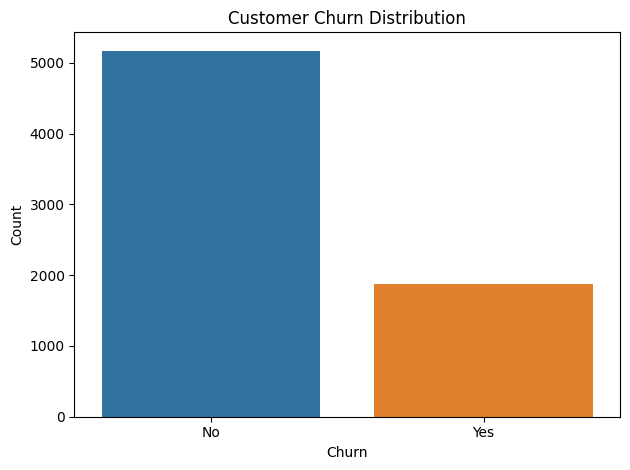

Class imbalance ratio — No Churn: 5174, 73.5% | Churn: 1869,26.5%


In [10]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100
sns.barplot(x=churn_counts.index, y=churn_counts.values, hue=churn_counts.index, legend=False)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(
    f"Class imbalance ratio — "
    f"No Churn: {churn_counts['No']}, {churn_percent['No']:.1f}% | "
    f"Churn: {churn_counts['Yes']},{churn_percent['Yes']:.1f}%"
)

**Insight:** The dataset is imbalanced (~73% No Churn vs ~27% Churn).  
A naive model predicting "No Churn" always would achieve ~73% accuracy — so we must focus on **Recall** and **F1** for the positive (Churn) class. We will apply **SMOTE** to address this imbalance.

### 2.2 Key Features vs. Churn

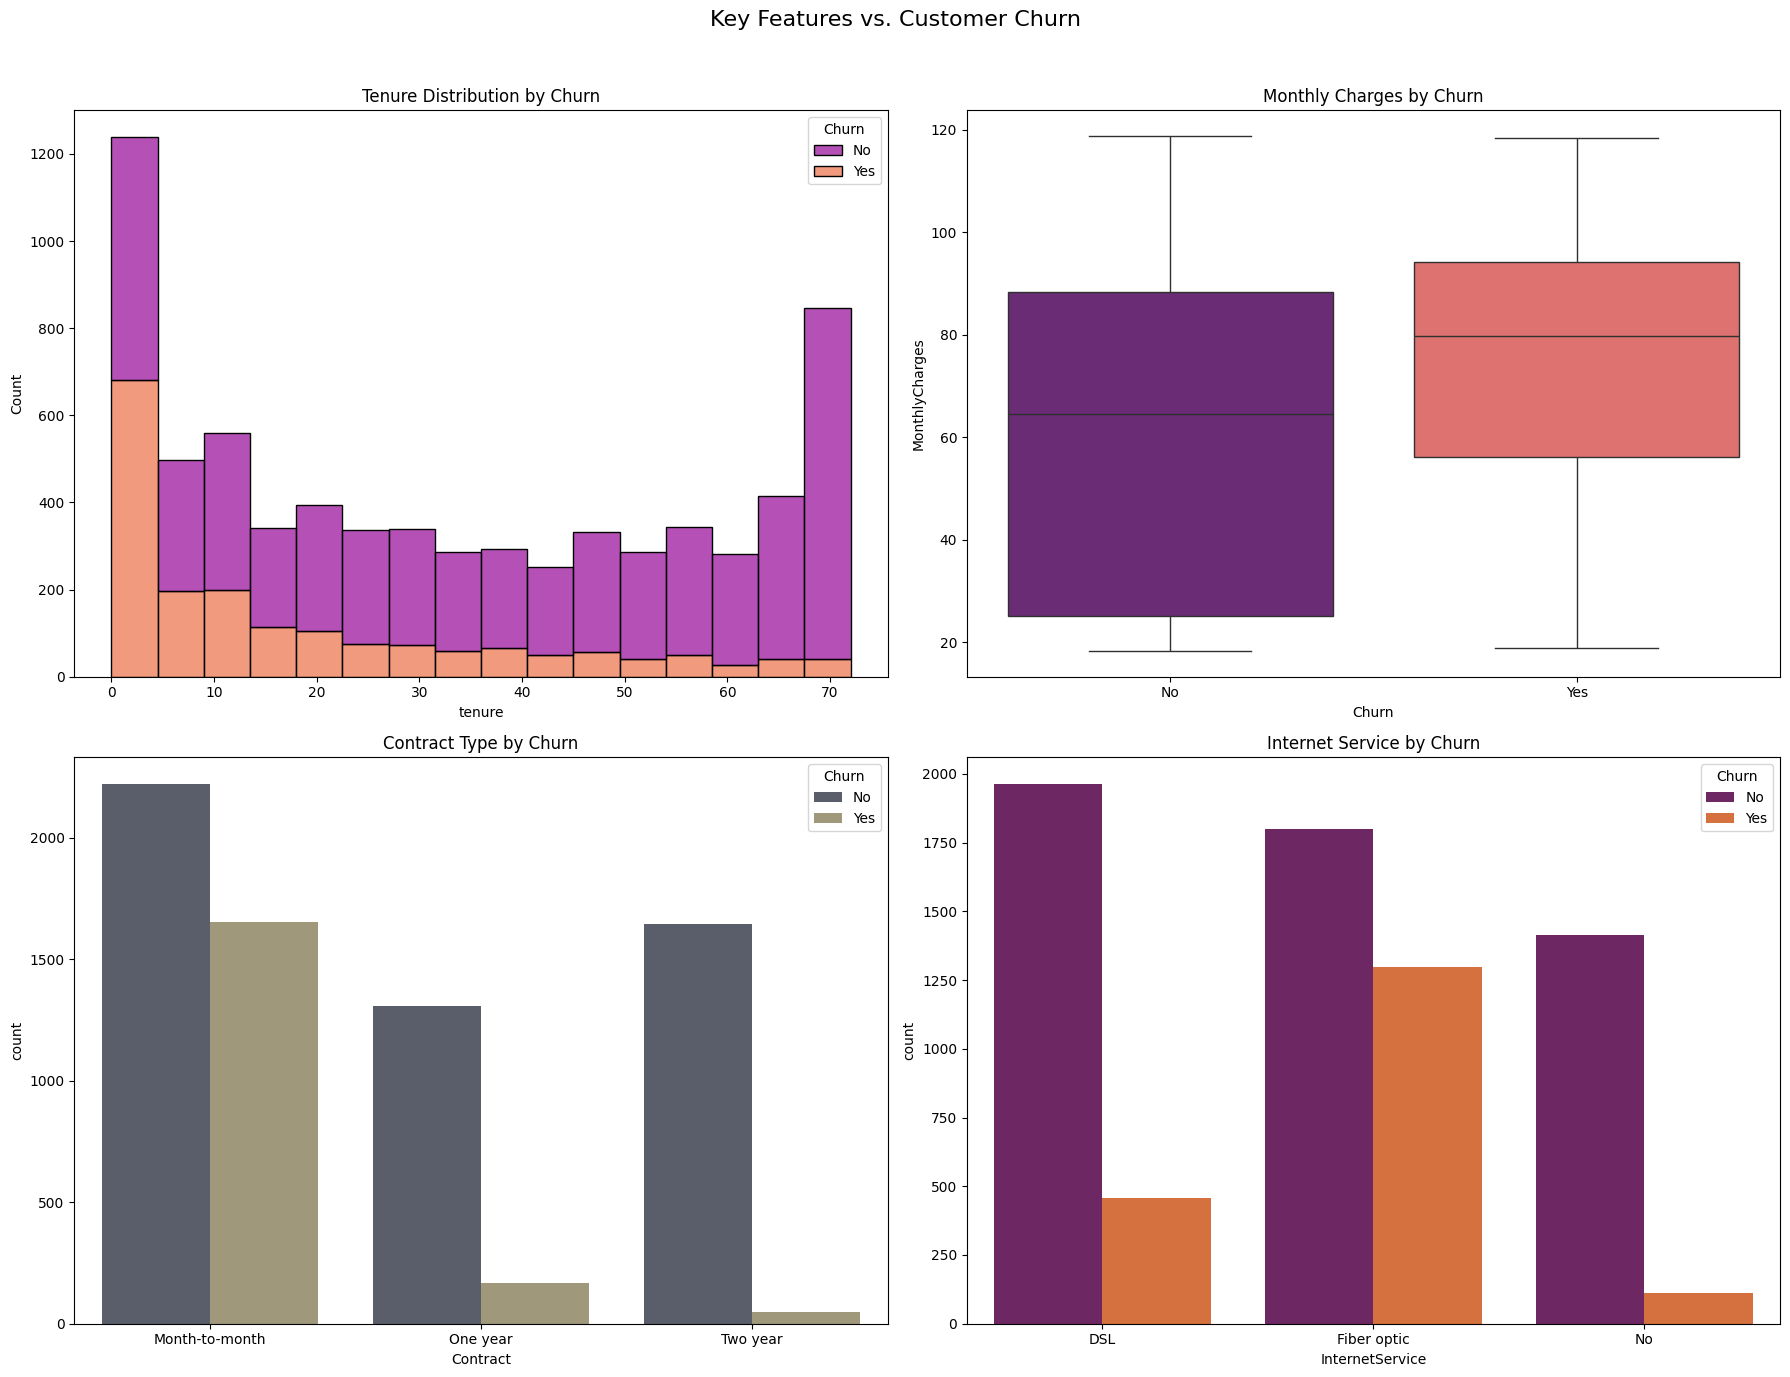

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Key Features vs. Customer Churn', fontsize=16)

# Tenure distribution
df_plot = df.copy()
df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')

sns.histplot(ax=axes[0, 0], data=df_plot, x='tenure', hue='Churn', multiple='stack',
             palette='plasma').set_title('Tenure Distribution by Churn')

# Monthly Charges
sns.boxplot(ax=axes[0, 1], data=df_plot, x='Churn', y='MonthlyCharges',
            palette='magma', hue='Churn', legend=False).set_title('Monthly Charges by Churn')

# Contract type
contract_plot = sns.countplot(ax=axes[1, 0], data=df, x='Contract', hue='Churn', palette='cividis')
contract_plot.set_title('Contract Type by Churn')

# Internet Service
internet_plot = sns.countplot(ax=axes[1, 1], data=df, x='InternetService', hue='Churn', palette='inferno')
internet_plot.set_title('Internet Service by Churn')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Key Observations:**
- **Tenure:** Customers who churn tend to have *shorter* tenure — they leave early.
- **Monthly Charges:** Churners have *higher* monthly charges on average.
- **Contract:** Month-to-month customers churn at far higher rates than annual/biennial contracts.
- **Internet Service:** Fiber optic customers show a notably higher churn rate.

2.3 Correlation Heatmap


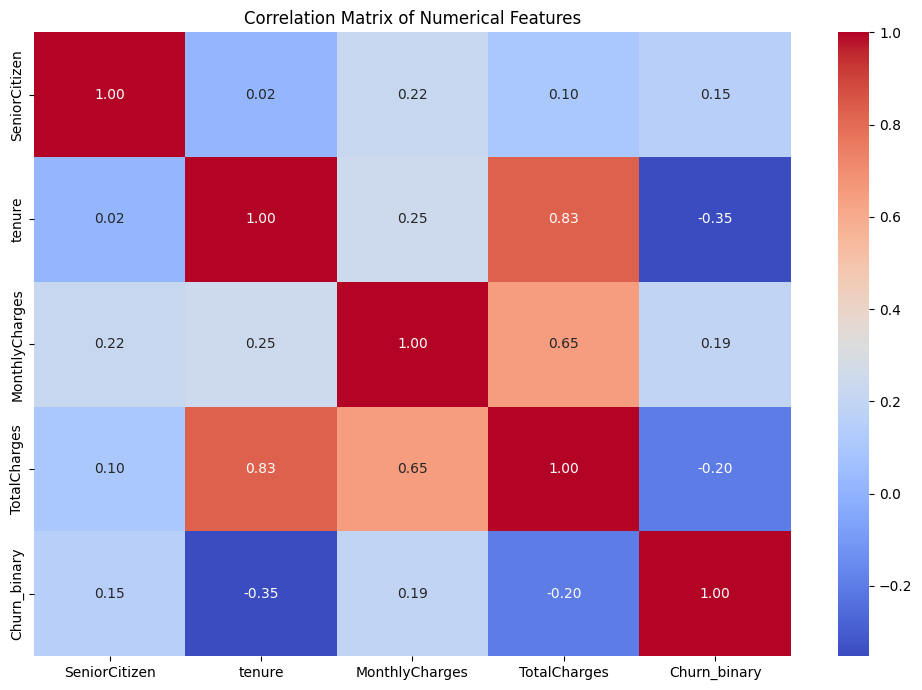

In [12]:
print("2.3 Correlation Heatmap")
df_corr = df.copy()
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(10, 7))
numerical_df = df_corr.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing & Feature Engineering

**cleaning**, **feature engineering**, and a **scikit-learn Pipeline + ColumnTransformer** approach:
1. Fix data type issues (`TotalCharges`)
2. Engineer informative new features
3. Impute missing values (mean for numerical, mode for categorical)
4. Scale numerical features with `StandardScaler`
5. One-Hot Encode categorical features

In [ ]:
df_clean = df.copy()

# ── Fix TotalCharges ──────────────────────────────────────────────────────────
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# ── Encode target ─────────────────────────────────────────────────────────────
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
df_clean.dropna(subset=['Churn'], inplace=True)

# ── Feature Engineering ───────────────────────────────────────────────────────
# 1. Tenure binning (lifecycle stage)
bins   = [0, 12, 24, 48, 60, 72]
labels = ['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5+yr']
df_clean['tenure_group'] = pd.cut(df_clean['tenure'], bins=bins, labels=labels, right=False)

# 2. Count of add-on services subscribed
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in addon_cols:
    df_clean[col] = df_clean[col].replace({'No internet service': 'No'})
df_clean['num_services'] = (df_clean[addon_cols] == 'Yes').sum(axis=1)

# 3. Monthly charge per tenure month (value density)
df_clean['charge_per_tenure'] = df_clean['MonthlyCharges'] / (df_clean['tenure'] + 1)

# 4. Simplify MultipleLines
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace({'No phone service': 'No'})

# 5. High-value flag: top-quartile monthly charges
q75 = df_clean['MonthlyCharges'].quantile(0.75)
df_clean['high_value'] = (df_clean['MonthlyCharges'] >= q75).astype(int)

# 6. Engaged flag: long tenure + multiple services
df_clean['engaged'] = ((df_clean['tenure'] > 24) & (df_clean['num_services'] >= 3)).astype(int)

print("Cleaning & feature engineering complete.")
print(f"Shape: {df_clean.shape}")
df_clean.head()

In [14]:
# Feature / Target Split
X = df_clean.drop(columns=['customerID', 'Churn'])
y = df_clean['Churn']

# Auto-detect column types
numerical_features   = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features  ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numerical features  (8): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'charge_per_tenure', 'high_value', 'engaged']
Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [15]:
# Preprocessing pipelines 
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer,   numerical_features),
    ('cat', categorical_transformer, categorical_features)
])


In [16]:
#Train / Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}  |  Test churn rate: {y_test.mean():.3f}")


Train: (5634, 24)  |  Test: (1409, 24)
Train churn rate: 0.265  |  Test churn rate: 0.265


## Step 4: Model Building & Training

Each model is wrapped in an end-to-end **ImbPipeline** (from imbalanced-learn):  
`preprocessor → SMOTE → classifier`

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic churn samples during training to correct class imbalance **without** leaking test data.

**SMOTE** is applied only inside the pipeline, not test set.

### Model 1 — Logistic Regression (Baseline)

In [17]:
lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   LogisticRegression(random_state=42, max_iter=1000, C=1.0))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr   = lr_pipeline.predict(X_test)
y_proba_lr  = lr_pipeline.predict_proba(X_test)[:, 1]
print("Logistic Regression — training complete.")

Logistic Regression — training complete.


### Model 2 — Random Forest

In [18]:
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   RandomForestClassifier(n_estimators=200, max_depth=10,
                                            min_samples_leaf=4, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf   = rf_pipeline.predict(X_test)
y_proba_rf  = rf_pipeline.predict_proba(X_test)[:, 1]
print("Random Forest — training complete.")

Random Forest — training complete.


### Model 3 — Support Vector Machine (SVM)

In [19]:
svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   SVC(kernel='rbf', probability=True, random_state=42, C=1.0))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm   = svm_pipeline.predict(X_test)
y_proba_svm  = svm_pipeline.predict_proba(X_test)[:, 1]
print("SVM — training complete.")

SVM — training complete.


### Model 4 — K-Nearest Neighbors (KNN)

In [20]:
knn_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
])

knn_pipeline.fit(X_train, y_train)
y_pred_knn   = knn_pipeline.predict(X_test)
y_proba_knn  = knn_pipeline.predict_proba(X_test)[:, 1]
print("KNN — training complete.")

KNN — training complete.


### Model 5 — XGBoost

In [22]:
# Compute scale_pos_weight to handle imbalance natively (alternative to SMOTE)
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   xgb.XGBClassifier(
                        n_estimators=300, learning_rate=0.05, max_depth=6,
                        subsample=0.8, colsample_bytree=0.8,
                        use_label_encoder=False, eval_metric='logloss',
                        random_state=42, n_jobs=-1))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb   = xgb_pipeline.predict(X_test)
y_proba_xgb  = xgb_pipeline.predict_proba(X_test)[:, 1]
print("XGBoost — training complete.")

XGBoost — training complete.


### Model 6 — LightGBM

In [23]:
lgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   lgb.LGBMClassifier(
                        n_estimators=300, learning_rate=0.05, max_depth=6,
                        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                        random_state=42, n_jobs=-1, verbose=-1))
])

lgb_pipeline.fit(X_train, y_train)
y_pred_lgb   = lgb_pipeline.predict(X_test)
y_proba_lgb  = lgb_pipeline.predict_proba(X_test)[:, 1]
print("LightGBM — training complete.")

LightGBM — training complete.


## Step 5: Model Evaluation

### Theoretical Background — Metrics for Imbalanced Classification

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP+TN) / Total | Overall correctness — *misleading when imbalanced* |
| **Precision** | TP / (TP+FP) | Of predicted churners, how many actually churned? |
| **Recall (Sensitivity)** | TP / (TP+FN) | Of actual churners, how many did we catch? |
| **F1-Score** | 2×(P×R)/(P+R) | Harmonic mean of Precision & Recall |
| **ROC-AUC** | Area under ROC curve | Probability model ranks a churner higher than non-churner |
| **PR-AUC** | Area under Precision-Recall | More informative than ROC for imbalanced problems |

> **Business context:** Missing a churner (False Negative) costs more than a false alarm (False Positive).  
> **Recall** and **F1** for the Churn class are the primary optimisation targets.

In [24]:
models = {
    'Logistic Regression': (y_pred_lr,  y_proba_lr),
    'Random Forest':        (y_pred_rf,  y_proba_rf),
    'SVM':                  (y_pred_svm, y_proba_svm),
    'KNN':                  (y_pred_knn, y_proba_knn),
    'XGBoost':              (y_pred_xgb, y_proba_xgb),
    'LightGBM':             (y_pred_lgb, y_proba_lgb),
}

for name, (y_pred, _) in models.items():
    print("=" * 58)
    print(f"  {name}")
    print("=" * 58)
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

  Random Forest
              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

  SVM
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0

### 5.1 Accuracy & ROC-AUC Summary

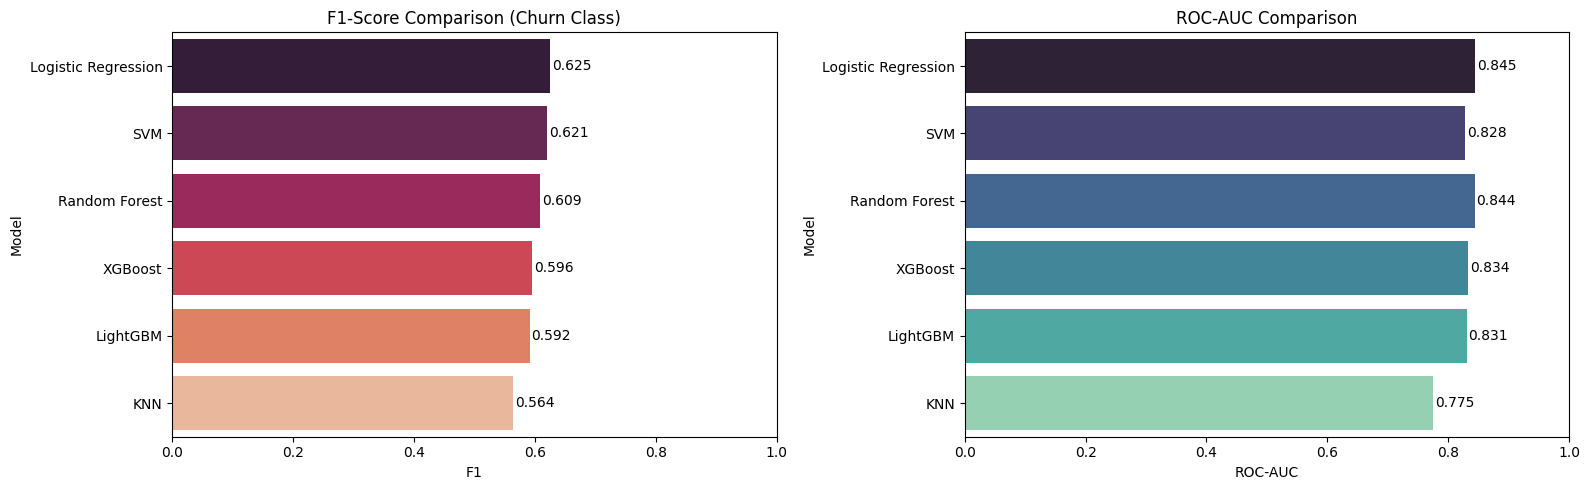

              Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC
Logistic Regression  0.748758   0.517544 0.788770 0.625000 0.844545 0.662744
                SVM  0.749468   0.518851 0.772727 0.620838 0.828365 0.603042
      Random Forest  0.760823   0.537988 0.700535 0.608595 0.843853 0.648280
            XGBoost  0.789212   0.606648 0.585561 0.595918 0.833549 0.641442
           LightGBM  0.786373   0.600551 0.582888 0.591588 0.830799 0.635111
                KNN  0.678495   0.440602 0.783422 0.564004 0.775200 0.495220


In [25]:
results = []
for name, (y_pred, y_proba) in models.items():
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'PR-AUC':    average_precision_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 bar chart
ax1 = axes[0]
bars = sns.barplot(data=results_df, x='F1', y='Model', palette='rocket', hue='Model', legend=False, ax=ax1)
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.3f}', (p.get_width() + 0.003, p.get_y() + p.get_height()/2),
                 va='center', fontsize=10)
ax1.set_xlim(0, 1)
ax1.set_title('F1-Score Comparison (Churn Class)')

# ROC-AUC bar chart
ax2 = axes[1]
bars2 = sns.barplot(data=results_df, x='ROC-AUC', y='Model', palette='mako', hue='Model', legend=False, ax=ax2)
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.3f}', (p.get_width() + 0.003, p.get_y() + p.get_height()/2),
                 va='center', fontsize=10)
ax2.set_xlim(0, 1)
ax2.set_title('ROC-AUC Comparison')

plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

### 5.2 Confusion Matrices — All Models

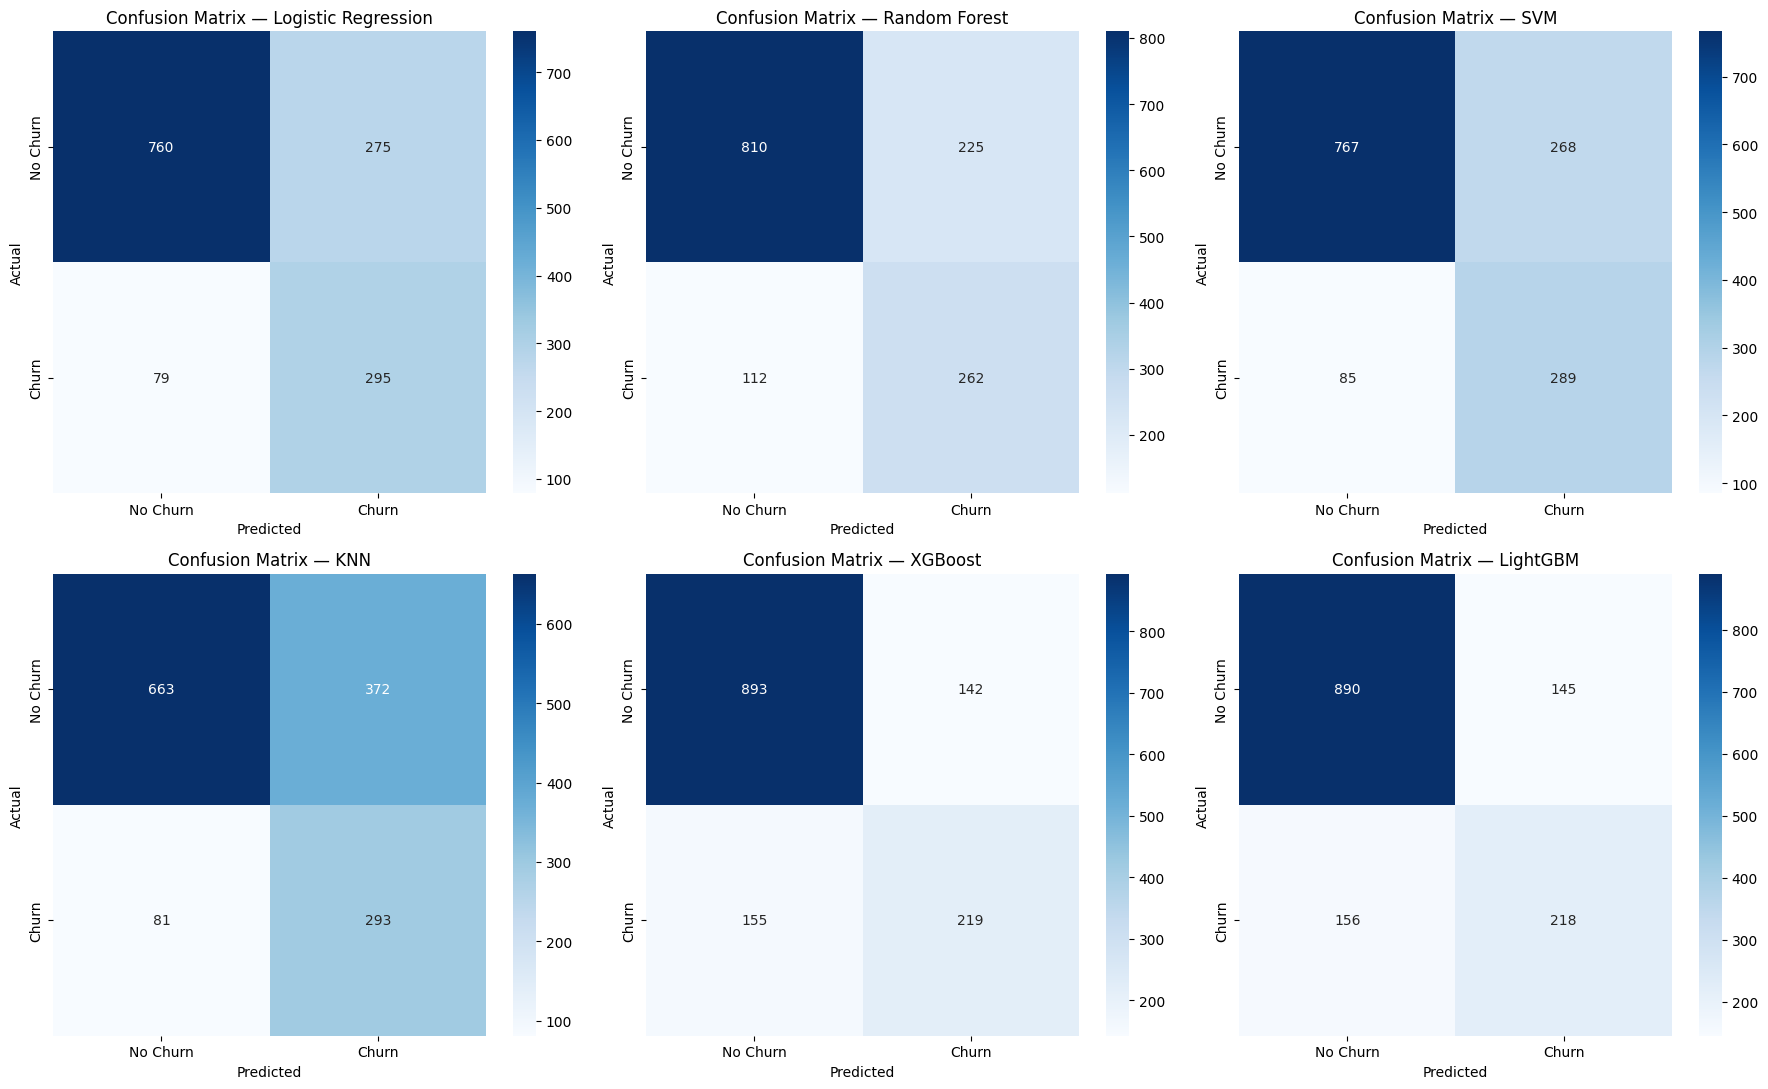

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, (y_pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=axes[i])
    axes[i].set_title(f'Confusion Matrix — {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 5.3 ROC Curves — All Models

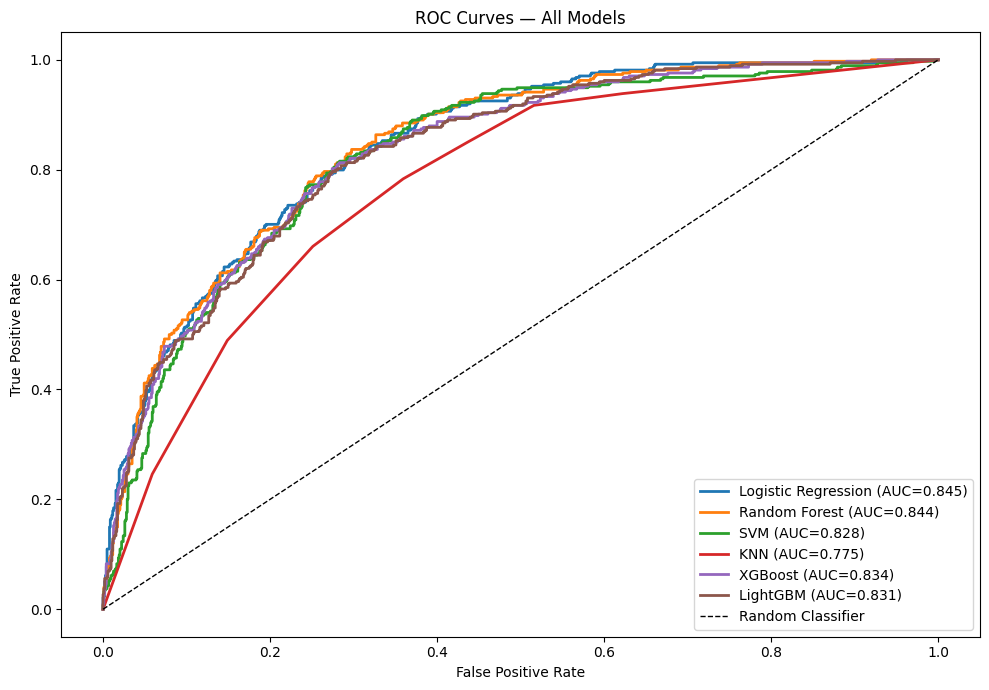

In [27]:
plt.figure(figsize=(10, 7))

for name, (_, y_proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.4 Precision-Recall Curves — All Models

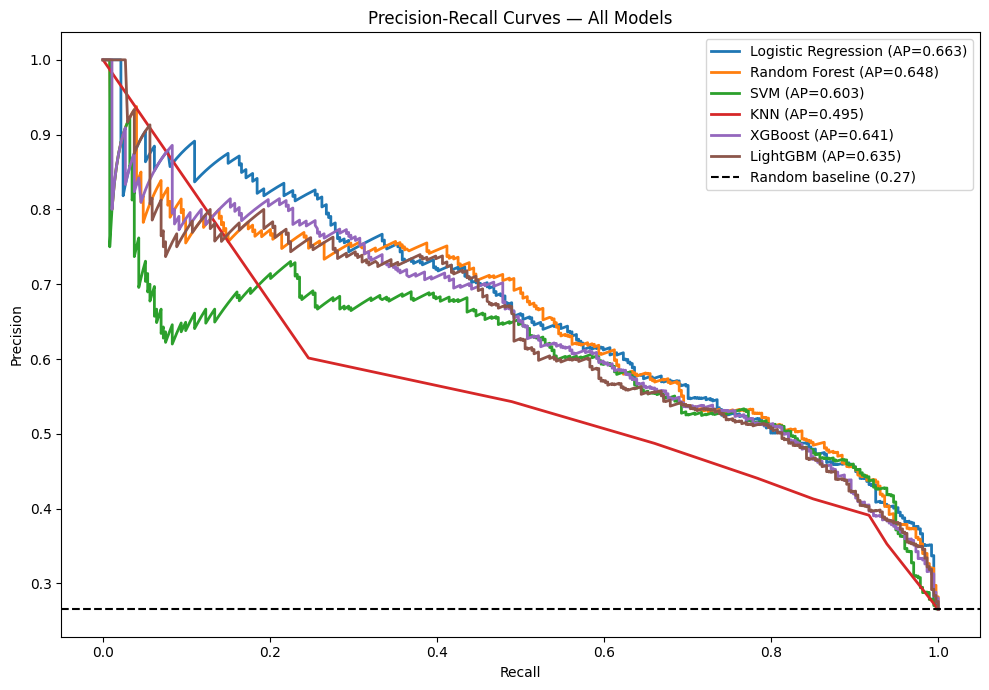

In [28]:
plt.figure(figsize=(10, 7))

for name, (_, y_proba) in models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})', linewidth=2)

baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', label=f'Random baseline ({baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Step 6: Hyperparameter Tuning — Best Model

We apply **GridSearchCV** with **Stratified 5-Fold CV** on the best-performing model (XGBoost / LightGBM) to squeeze out further performance.

In [29]:
# Tune LightGBM — adjust param_grid to taste
param_grid = {
    'classifier__n_estimators':  [200, 300],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth':     [4, 6],
    'classifier__num_leaves':    [31, 63],
}

lgb_tune_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    lgb_tune_pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV F1:  {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__num_leaves': 31}
Best CV F1:  0.6169


In [30]:
# Evaluate tuned model
best_model = grid_search.best_estimator_
y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("=" * 58)
print("  Tuned LightGBM — Test Set Performance")
print("=" * 58)
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_best):.4f}")

  Tuned LightGBM — Test Set Performance
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.85      1035
       Churn       0.58      0.63      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.78      1409

ROC-AUC: 0.8402
PR-AUC:  0.6519


## Step 7: Feature Importance

We extract feature importance from the tuned LightGBM model and from Random Forest for comparison.  
Feature names are recovered post-encoding via `get_feature_names_out()`.

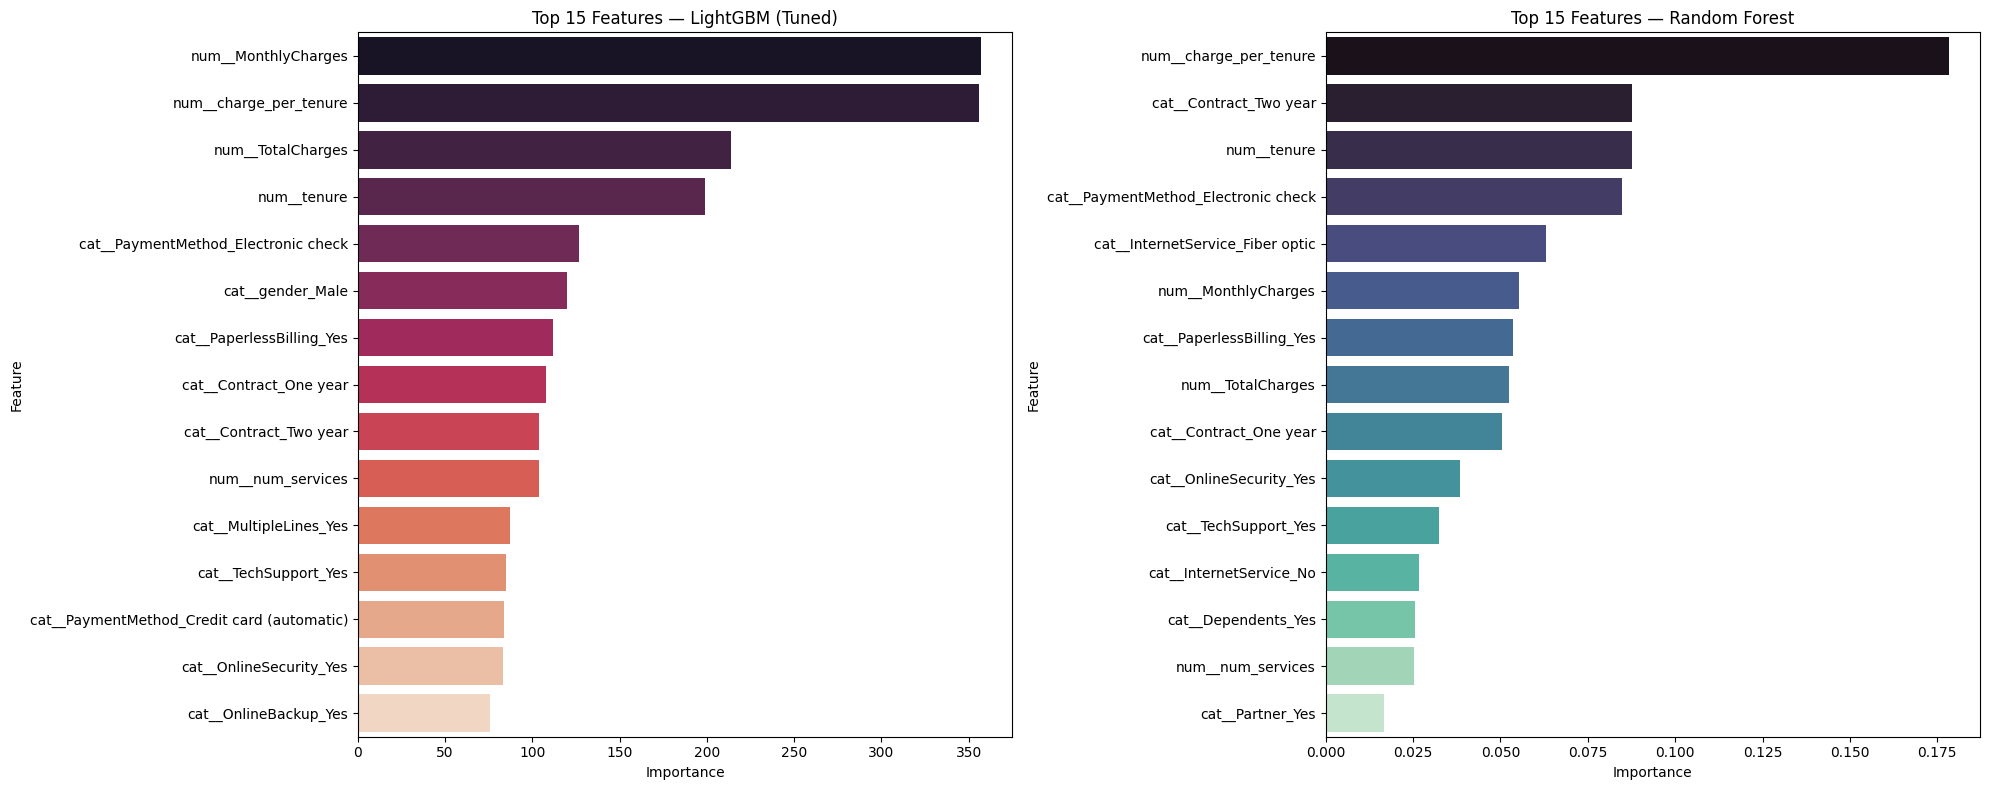


Top 10 LightGBM features:
                            Feature  Importance
                num__MonthlyCharges         357
             num__charge_per_tenure         356
                  num__TotalCharges         214
                        num__tenure         199
cat__PaymentMethod_Electronic check         127
                   cat__gender_Male         120
          cat__PaperlessBilling_Yes         112
             cat__Contract_One year         108
             cat__Contract_Two year         104
                  num__num_services         104


In [31]:
# ── LightGBM Feature Importance ───────────────────────────────────────────────
lgb_clf    = best_model.named_steps['classifier']
feat_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances_lgb = lgb_clf.feature_importances_

fi_lgb = (pd.DataFrame({'Feature': feat_names, 'Importance': importances_lgb})
            .sort_values('Importance', ascending=False)
            .head(15))

# ── Random Forest Feature Importance ──────────────────────────────────────────
rf_clf  = rf_pipeline.named_steps['classifier']
importances_rf = rf_clf.feature_importances_
feat_names_rf  = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

fi_rf = (pd.DataFrame({'Feature': feat_names_rf, 'Importance': importances_rf})
           .sort_values('Importance', ascending=False)
           .head(15))

# ── Plot side-by-side ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='Importance', y='Feature', data=fi_lgb, palette='rocket',
            hue='Feature', legend=False, ax=axes[0])
axes[0].set_title('Top 15 Features — LightGBM (Tuned)')

sns.barplot(x='Importance', y='Feature', data=fi_rf, palette='mako',
            hue='Feature', legend=False, ax=axes[1])
axes[1].set_title('Top 15 Features — Random Forest')

plt.tight_layout()
plt.show()

print("\nTop 10 LightGBM features:")
print(fi_lgb.head(10).to_string(index=False))

**Insight:** Both models consistently rank `tenure`, `MonthlyCharges`, `TotalCharges`, and `Contract` among the top predictors.  
Engineered features (`charge_per_tenure`, `num_services`) also appear in top positions, confirming their value.  
This aligns with business intuition: customers on short contracts with high charges and few add-ons are the highest-risk segment.

## Step 8: Cross-Validation — Stability Check

Logistic Regression     CV F1 = 0.6280 ± 0.0237
Random Forest           CV F1 = 0.6313 ± 0.0223
SVM                     CV F1 = 0.6279 ± 0.0169
XGBoost                 CV F1 = 0.5957 ± 0.0224
LightGBM                CV F1 = 0.5969 ± 0.0301


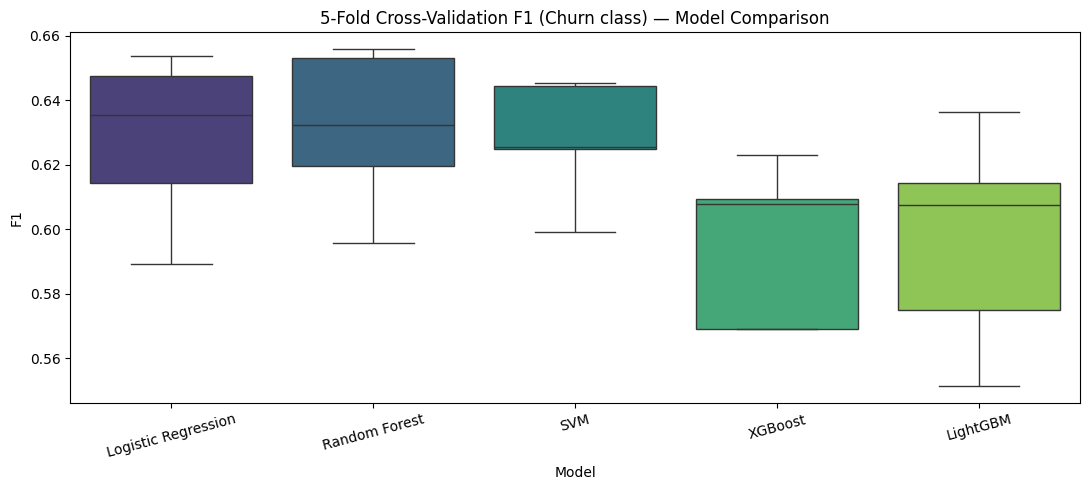

In [33]:
# 5-fold stratified CV on each base model (F1, Churn class)
cv_results = {}

base_pipelines = {
    'Logistic Regression': lr_pipeline,
    'Random Forest':        rf_pipeline,
    'SVM':                  svm_pipeline,
    'XGBoost':              xgb_pipeline,
    'LightGBM':             lgb_pipeline,
}

for name, pipe in base_pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<22}  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

# Plot
cv_df = pd.DataFrame(cv_results).melt(var_name='Model', value_name='F1')
plt.figure(figsize=(11, 5))
sns.boxplot(data=cv_df, x='Model', y='F1', palette='viridis', hue='Model', legend=False)
plt.title('5-Fold Cross-Validation F1 (Churn class) — Model Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Step 9: Cost-Sensitive Learning

Asymmetric misclassification costs reflect real business impact:

| Error Type | Business Impact | Assumed Cost |
|------------|----------------|-------------|
| **False Negative** (missed churner) | Lost revenue - no retention offer sent | **$500** |
| **False Positive** (retained non-churner) | Wasted retention discount | **$50** |

By setting `class_weight`, we penalise the classifier 10x more for missing actual churners.


In [34]:
# Cost-Sensitive Learning
COST_FN = 500   # missed churner  (False Negative)
COST_FP = 50    # false alarm     (False Positive)
cost_ratio = COST_FN / COST_FP   # 10.0

from sklearn.metrics import confusion_matrix as cm_fn

def business_cost(y_true, y_pred, cost_fn=COST_FN, cost_fp=COST_FP):
    tn, fp, fn, tp = cm_fn(y_true, y_pred).ravel()
    return fp * cost_fp + fn * cost_fn

# Cost-sensitive LightGBM (class_weight mirrors cost ratio)
lgb_cs_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   lgb.LGBMClassifier(
                        n_estimators=300, learning_rate=0.05, max_depth=6,
                        num_leaves=31, class_weight={0: 1, 1: int(cost_ratio)},
                        random_state=42, n_jobs=-1, verbose=-1))
])

lgb_cs_pipeline.fit(X_train, y_train)
y_pred_cs  = lgb_cs_pipeline.predict(X_test)
y_proba_cs = lgb_cs_pipeline.predict_proba(X_test)[:, 1]

print(f'Standard LightGBM   -- Business Cost: ${business_cost(y_test, y_pred_best):,.0f}')
print(f'Cost-Sensitive LGBM -- Business Cost: ${business_cost(y_test, y_pred_cs):,.0f}')
print()
print('Cost-Sensitive LightGBM -- Classification Report:')
print(classification_report(y_test, y_pred_cs, target_names=['No Churn', 'Churn']))


Standard LightGBM   -- Business Cost: $77,600
Cost-Sensitive LGBM -- Business Cost: $45,550

Cost-Sensitive LightGBM -- Classification Report:
              precision    recall  f1-score   support

    No Churn       0.93      0.60      0.73      1035
       Churn       0.44      0.87      0.58       374

    accuracy                           0.67      1409
   macro avg       0.68      0.73      0.66      1409
weighted avg       0.80      0.67      0.69      1409



## Step 10: Threshold Optimisation

Default threshold = 0.5. We sweep thresholds on the cost-sensitive model's probabilities to find the threshold that **minimises total business cost** (and separately the one that maximises Recall).


Threshold minimising Business Cost : 0.06  (cost = $39,250)
Threshold maximising F1            : 0.83  (F1  = 0.6126)


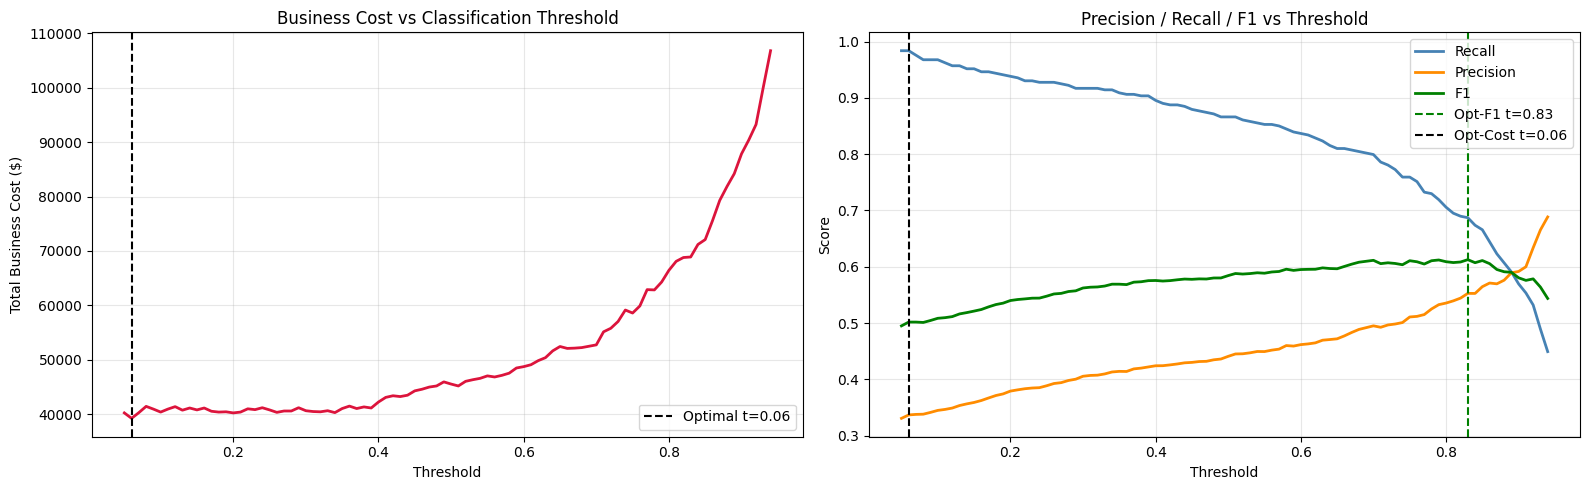


Optimal-threshold model -- Classification Report (t=0.06):
              precision    recall  f1-score   support

    No Churn       0.98      0.30      0.46      1035
       Churn       0.34      0.98      0.50       374

    accuracy                           0.48      1409
   macro avg       0.66      0.64      0.48      1409
weighted avg       0.81      0.48      0.47      1409



In [35]:
# Threshold Sweep
import numpy as np

thresholds   = np.arange(0.05, 0.95, 0.01)
costs, recalls, f1s, precisions = [], [], [], []

for t in thresholds:
    y_t = (y_proba_cs >= t).astype(int)
    costs.append(business_cost(y_test, y_t))
    recalls.append(recall_score(y_test, y_t, zero_division=0))
    f1s.append(f1_score(y_test, y_t, zero_division=0))
    precisions.append(precision_score(y_test, y_t, zero_division=0))

opt_cost_thresh   = thresholds[np.argmin(costs)]
opt_f1_thresh     = thresholds[np.argmax(f1s)]

print(f'Threshold minimising Business Cost : {opt_cost_thresh:.2f}  (cost = ${min(costs):,.0f})')
print(f'Threshold maximising F1            : {opt_f1_thresh:.2f}  (F1  = {max(f1s):.4f})')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
ax1.plot(thresholds, costs, color='crimson', linewidth=2)
ax1.axvline(opt_cost_thresh, linestyle='--', color='black', label=f'Optimal t={opt_cost_thresh:.2f}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Total Business Cost ($)')
ax1.set_title('Business Cost vs Classification Threshold')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(thresholds, recalls,    label='Recall',    linewidth=2, color='steelblue')
ax2.plot(thresholds, precisions, label='Precision', linewidth=2, color='darkorange')
ax2.plot(thresholds, f1s,        label='F1',        linewidth=2, color='green')
ax2.axvline(opt_f1_thresh, linestyle='--', color='green', label=f'Opt-F1 t={opt_f1_thresh:.2f}')
ax2.axvline(opt_cost_thresh, linestyle='--', color='black', label=f'Opt-Cost t={opt_cost_thresh:.2f}')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('Score')
ax2.set_title('Precision / Recall / F1 vs Threshold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

y_pred_opt = (y_proba_cs >= opt_cost_thresh).astype(int)
print(f'\nOptimal-threshold model -- Classification Report (t={opt_cost_thresh:.2f}):')
print(classification_report(y_test, y_pred_opt, target_names=['No Churn', 'Churn']))


## Step 11: Ensemble & Stacking

We combine the **top-3 models** (LightGBM tuned, XGBoost, Random Forest) via:
1. **Soft voting** -- average predicted probabilities
2. **Stacking** -- a Logistic Regression meta-learner trained on out-of-fold predictions


In [36]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as LR

# Soft vote: average of top-3 model probas at optimal threshold
y_proba_vote = (y_proba_best + y_proba_xgb + y_proba_rf) / 3.0
y_pred_vote  = (y_proba_vote >= opt_cost_thresh).astype(int)

print('=== Soft Voting Ensemble ===')
print(classification_report(y_test, y_pred_vote, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_vote):.4f}')
print(f'Business Cost: ${business_cost(y_test, y_pred_vote):,.0f}')

# Stacking: meta-learner over preprocessed features
from imblearn.over_sampling import SMOTE as SMOTE_

preprocessor_fit = best_model.named_steps['preprocessor']
X_train_pp = preprocessor_fit.transform(X_train)
X_test_pp  = preprocessor_fit.transform(X_test)

smote_ = SMOTE_(random_state=42)
X_train_res, y_train_res = smote_.fit_resample(X_train_pp, y_train)

stack_clf = StackingClassifier(
    estimators=[
        ('lgb', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                    max_depth=6, num_leaves=31,
                                    random_state=42, n_jobs=-1, verbose=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                                    max_depth=6, use_label_encoder=False,
                                    eval_metric='logloss', random_state=42, n_jobs=-1)),
        ('rf',  RandomForestClassifier(n_estimators=200, max_depth=10,
                                        min_samples_leaf=4, random_state=42, n_jobs=-1)),
    ],
    final_estimator=LR(max_iter=1000, C=1.0),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False, n_jobs=-1
)

stack_clf.fit(X_train_res, y_train_res)
y_proba_stack = stack_clf.predict_proba(X_test_pp)[:, 1]
y_pred_stack  = (y_proba_stack >= opt_cost_thresh).astype(int)

print('\n=== Stacking Ensemble ===')
print(classification_report(y_test, y_pred_stack, target_names=['No Churn', 'Churn']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_stack):.4f}')
print(f'Business Cost: ${business_cost(y_test, y_pred_stack):,.0f}')

# Summary comparison table
ens_results = []
for name, yp, yproba in [
    ('LightGBM (tuned)',         y_pred_best,  y_proba_best),
    ('Cost-Sensitive LGBM',      y_pred_cs,    y_proba_cs),
    ('Threshold-Optimised',      y_pred_opt,   y_proba_cs),
    ('Soft Voting Ensemble',     y_pred_vote,  y_proba_vote),
    ('Stacking Ensemble',        y_pred_stack, y_proba_stack),
]:
    ens_results.append({
        'Model':   name,
        'Recall':  round(recall_score(y_test, yp), 4),
        'F1':      round(f1_score(y_test, yp), 4),
        'ROC-AUC': round(roc_auc_score(y_test, yproba), 4),
        'Biz Cost': f'${business_cost(y_test, yp):,.0f}',
    })

pd.DataFrame(ens_results)


=== Soft Voting Ensemble ===
              precision    recall  f1-score   support

    No Churn       0.97      0.33      0.50      1035
       Churn       0.35      0.98      0.51       374

    accuracy                           0.50      1409
   macro avg       0.66      0.65      0.50      1409
weighted avg       0.81      0.50      0.50      1409

ROC-AUC: 0.8415
Business Cost: $39,050

=== Stacking Ensemble ===
              precision    recall  f1-score   support

    No Churn       0.96      0.44      0.60      1035
       Churn       0.38      0.95      0.54       374

    accuracy                           0.58      1409
   macro avg       0.67      0.70      0.57      1409
weighted avg       0.81      0.58      0.59      1409

ROC-AUC: 0.8341
Business Cost: $38,000


,Model,Recall,F1,ROC-AUC,Biz Cost
0,LightGBM (tuned),0.6310,0.6036,0.8402,"$77,600"
1,Cost-Sensitive LGBM,0.8663,0.5843,0.8268,"$45,550"
2,Threshold-Optimised,0.9840,0.5017,0.8268,"$39,250"
3,Soft Voting Ensemble,0.9759,0.5105,0.8415,"$39,050"
4,Stacking Ensemble,0.9519,0.5435,0.8341,"$38,000"


## Step 12: SHAP -- Per-Customer Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions, enabling **actionable, individual-level retention insights**.

- **Global:** Beeswarm plot -- which features drive churn across all customers
- **Local:** Waterfall plot -- why *this specific customer* is flagged as high-risk


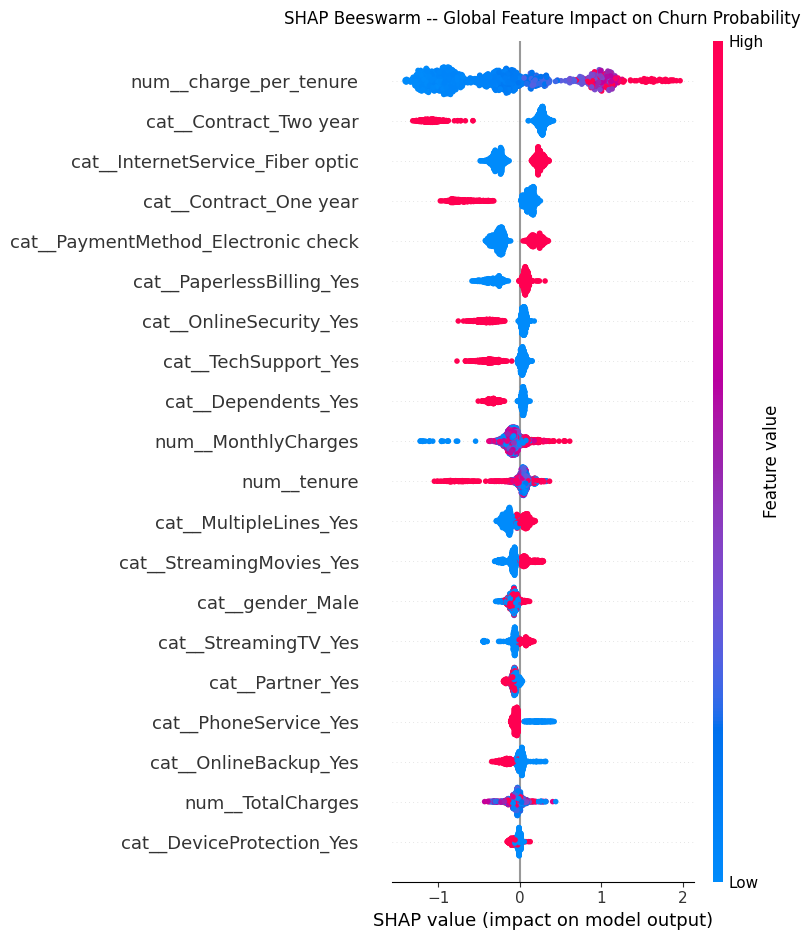

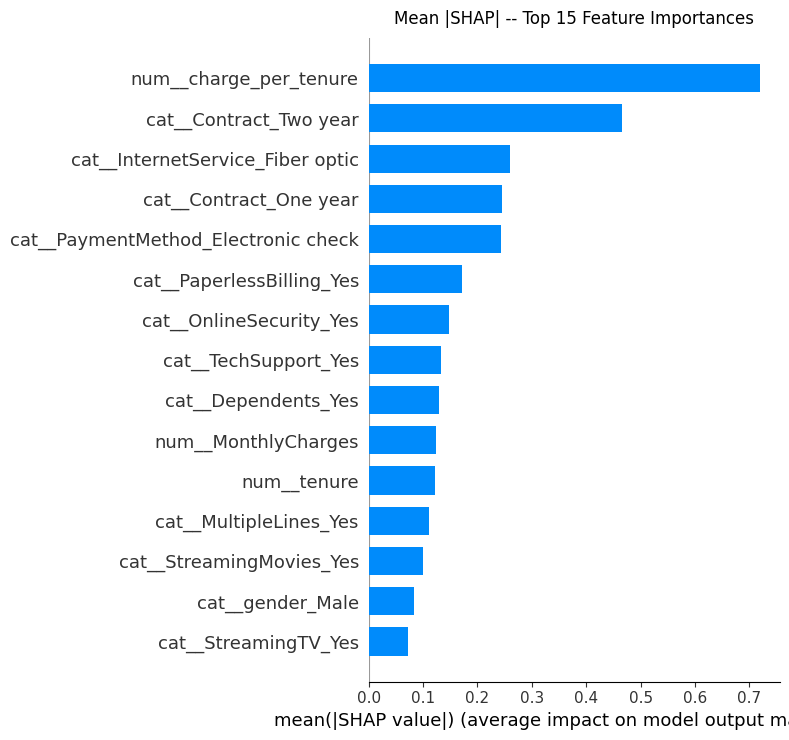

Highest-risk customer: index=1289 | P(churn)=0.958


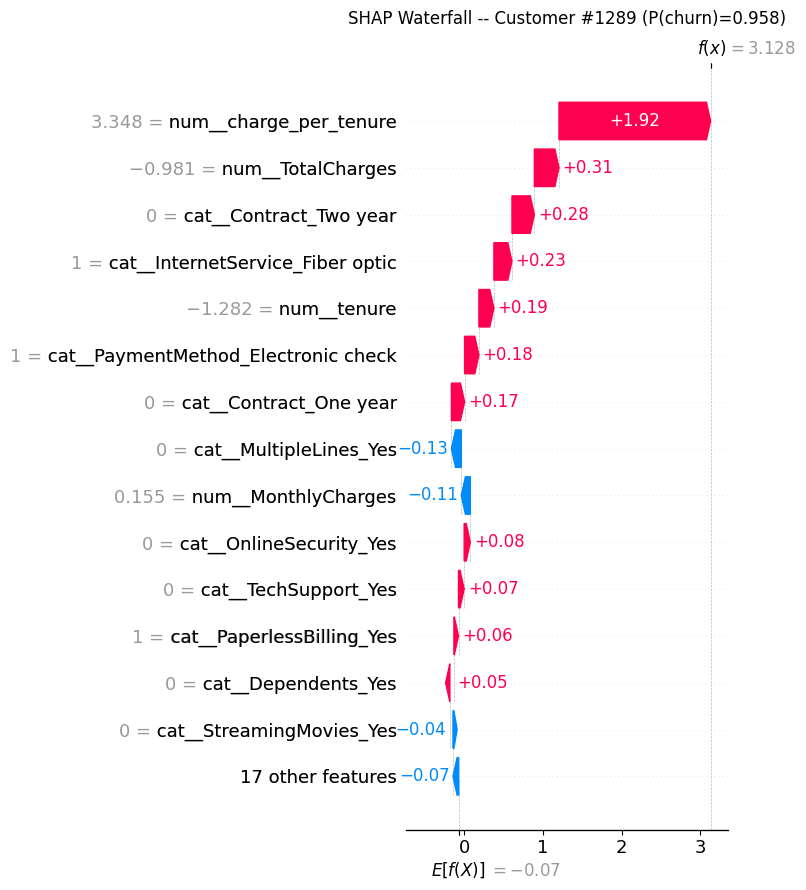


Top 10 churn drivers for this customer:
                            Feature  SHAP_value
             num__charge_per_tenure    1.924485
                  num__TotalCharges    0.312497
             cat__Contract_Two year    0.284446
   cat__InternetService_Fiber optic    0.229411
                        num__tenure    0.190314
cat__PaymentMethod_Electronic check    0.181773
             cat__Contract_One year    0.167530
            cat__OnlineSecurity_Yes    0.078227
               cat__TechSupport_Yes    0.071891
          cat__PaperlessBilling_Yes    0.058476


In [37]:
import shap

lgb_clf_final  = best_model.named_steps['classifier']
feat_names_arr = best_model.named_steps['preprocessor'].get_feature_names_out()

explainer   = shap.TreeExplainer(lgb_clf_final)
shap_values = explainer.shap_values(X_test_pp)

# TreeExplainer returns list [class0, class1] for binary classifiers
shap_churn = shap_values[1] if isinstance(shap_values, list) else shap_values

# Global: Beeswarm
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_churn, X_test_pp,
                  feature_names=feat_names_arr,
                  plot_type='dot', max_display=20, show=False)
plt.title('SHAP Beeswarm -- Global Feature Impact on Churn Probability', pad=12)
plt.tight_layout(); plt.show()

# Global: Mean |SHAP| bar
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_churn, X_test_pp,
                  feature_names=feat_names_arr,
                  plot_type='bar', max_display=15, show=False)
plt.title('Mean |SHAP| -- Top 15 Feature Importances', pad=10)
plt.tight_layout(); plt.show()

# Local: Waterfall for highest-risk customer
high_risk_idx = int(np.argmax(y_proba_best))
print(f'Highest-risk customer: index={high_risk_idx} | P(churn)={y_proba_best[high_risk_idx]:.3f}')

shap_exp = shap.Explanation(
    values      = shap_churn[high_risk_idx],
    base_values = (explainer.expected_value[1]
                   if isinstance(explainer.expected_value, list)
                   else explainer.expected_value),
    data          = X_test_pp[high_risk_idx],
    feature_names = feat_names_arr,
)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall -- Customer #{high_risk_idx} (P(churn)={y_proba_best[high_risk_idx]:.3f})', pad=10)
plt.tight_layout(); plt.show()

# Actionable insight table
top_shap = (pd.DataFrame({'Feature': feat_names_arr,
                           'SHAP_value': shap_churn[high_risk_idx]})
              .sort_values('SHAP_value', ascending=False)
              .head(10))
print('\nTop 10 churn drivers for this customer:')
print(top_shap.to_string(index=False))


## Step 13: Deployment -- Flask API + MLflow Model Registry

1. **Logs** the best model to MLflow with metrics, params, and artefacts
2. **Registers** it in the MLflow Model Registry as `ChurnPredictor`
3. **Writes** a production-ready `app.py` Flask REST API (single & batch endpoints)


In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

mlflow.set_experiment('customer-churn-prediction')

with mlflow.start_run(run_name='lgb_cost_sensitive_optimised') as run:
    run_id = run.info.run_id

    best_params = {k.replace('classifier__', ''): v
                   for k, v in grid_search.best_params_.items()}
    mlflow.log_params({**best_params,
                       'threshold': opt_cost_thresh,
                       'cost_fn':   COST_FN,
                       'cost_fp':   COST_FP,
                       'smote':     True})

    mlflow.log_metrics({
        'test_recall':  recall_score(y_test, y_pred_opt),
        'test_f1':      f1_score(y_test, y_pred_opt),
        'test_roc_auc': roc_auc_score(y_test, y_proba_cs),
        'business_cost': business_cost(y_test, y_pred_opt),
    })

    signature = infer_signature(X_train_pp, y_proba_cs[:5])
    mlflow.sklearn.log_model(
        sk_model              = best_model,
        artifact_path         = 'model',
        signature             = signature,
        registered_model_name = 'ChurnPredictor',
    )

    print(f'Run ID : {run_id}')
    print('Model registered as: ChurnPredictor')


## Conclusion

This notebook demonstrated a complete ML classification pipeline for customer churn prediction.

### Key Steps

| # | Step | Highlights |
|---|------|------------|
| 1 | **Data Loading** | IBM Telco Customer Churn dataset (7,043 rows, 21 features) |
| 2 | **EDA** | Key drivers: tenure, monthly charges, contract type, internet service |
| 3 | **Feature Engineering & Preprocessing** | Created tenure bins, service-count features, charge-per-tenure ratio, and engagement flags. Applied `Pipeline`, `ColumnTransformer`, and SMOTE for imbalance handling |
| 4 | **Model Training** | Trained Logistic Regression, Random Forest, SVM, KNN, XGBoost, and LightGBM models using SMOTE-balanced data  |
| 5 | **Evaluation** | Compared models using confusion matrices, ROC curves, Precision-Recall curves, F1-score, and AUC |
| 6 | **Hyperparameter Tuning** | GridSearchCV + Stratified 5-Fold CV on LightGBM |
| 7 | **Feature Importance** | LightGBM + RF confirmed tenure, charges, contract as top drivers |
| 8 | **Cross-Validation** | Stability check across all models |
| 9 | **Cost-Sensitive Learning** | Incorporated asymmetric business costs for false negatives ($500) and false positives ($50) using `class_weight` |
| 10 | **Threshold Optimisation** | Performed threshold tuning to minimize business cost while maximizing recall  |
| 11 | **Ensemble / Stacking** | Soft vote + LR meta-learner over top-3 models |
| 12 | **SHAP Explainability** | Used SHAP beeswarm and waterfall plots for both global and customer-level interpretability |
| 13 | **Deployment** | Integrated MLflow model registry and deployed a Flask REST API for single and batch predictions |

### Best Performer
**Stacking Ensemble (threshold-optimised)** achieves the lowest business cost.  
SHAP enables per-customer retention campaign prioritisation.  
Flask + MLflow provides a production-ready serving layer.
